In [5]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [67]:
# Stocks selected for analysis
stocks = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "NVIDIA": "NVDA"
}

In [1]:
def download_stocks_data(stocks_dict, period="1y"):
   
    stocks_data = {}

    for name, ticker in stocks_dict.items():

        print(f"Downloading {name} ({ticker})...")

        data = yf.Ticker(ticker).history(period=period)

        stocks_data[name] = data

    print("\nAll stocks downloaded successfully!")

    return stocks_data


In [10]:
stocks_data = download_stocks_data(stocks)


All stocks downloaded successfully!


In [11]:
stocks_data["Apple"]

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-07-03 00:00:00-04:00,211.311669,213.801790,210.973016,212.706146,34955800,0.0,0.0
2025-07-07 00:00:00-04:00,211.839569,215.375544,207.974912,209.120361,50229000,0.0,0.0
2025-07-08 00:00:00-04:00,209.269786,210.594517,207.626297,209.180130,42848900,0.0,0.0
2025-07-09 00:00:00-04:00,208.702041,210.494931,206.401171,210.305679,48749400,0.0,0.0
2025-07-10 00:00:00-04:00,209.678147,212.636412,209.200048,211.570648,44443600,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-26 00:00:00-04:00,275.000000,285.950012,274.209991,283.779999,261775500,0.0,0.0
2026-06-29 00:00:00-04:00,286.730011,288.369995,279.850006,281.739990,66427000,0.0,0.0
2026-06-30 00:00:00-04:00,281.170013,289.940002,280.700012,289.359985,65100200,0.0,0.0


In [12]:
stocks_data["Microsoft"]

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-07-03 00:00:00-04:00,489.896915,496.166841,489.529852,494.887054,13984800,0.0,0.0
2025-07-07 00:00:00-04:00,493.438607,494.797746,491.305651,493.775909,13981600,0.0,0.0
2025-07-08 00:00:00-04:00,493.299713,494.252128,490.194512,492.684631,11846600,0.0,0.0
2025-07-09 00:00:00-04:00,496.335465,502.764127,495.779905,499.520050,18659500,0.0,0.0
2025-07-10 00:00:00-04:00,499.063670,500.442670,493.805681,497.506134,16492100,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-26 00:00:00-04:00,357.149994,376.609985,355.429993,372.970001,186201600,0.0,0.0
2026-06-29 00:00:00-04:00,377.500000,380.500000,359.899994,368.570007,51229900,0.0,0.0
2026-06-30 00:00:00-04:00,371.029999,374.149994,367.450012,373.019989,44945700,0.0,0.0


In [13]:
stocks_data["NVIDIA"]

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-07-03 00:00:00-04:00,158.159341,160.765870,157.560148,159.128052,143716100,0.0,0.0
2025-07-07 00:00:00-04:00,157.989570,159.098095,157.130714,158.029526,140139000,0.0,0.0
2025-07-08 00:00:00-04:00,159.118079,160.006894,158.179327,159.787186,138133000,0.0,0.0
2025-07-09 00:00:00-04:00,161.005550,164.201290,160.945632,162.663345,183656400,0.0,0.0
2025-07-10 00:00:00-04:00,164.101438,164.281191,161.395036,163.881729,167704100,0.0,0.0
...,...,...,...,...,...,...,...
2026-06-26 00:00:00-04:00,193.119995,195.550003,191.220001,192.529999,179304100,0.0,0.0
2026-06-29 00:00:00-04:00,193.850006,196.179993,189.800003,194.970001,148835700,0.0,0.0
2026-06-30 00:00:00-04:00,197.240005,200.630005,195.110001,200.089996,166476700,0.0,0.0


In [58]:
#Summary of current price and market cap
summary = []

for name, ticker_symbol in stocks.items():

    ticker = yf.Ticker(ticker_symbol)
    info = ticker.info

    price = info.get("currentPrice") or info.get("regularMarketPrice")
    market_cap = info.get("marketCap")
    pe_ratio = info.get("trailingPE")
    volume = (
        info.get("volume24Hr")
        or info.get("regularMarketVolume24hr")
        or info.get("volume")
    )

    summary.append({
        "Stocks": name,
        "Ticker": ticker_symbol,
        "Current Price (USD)": price,
        "PE Ratio": pe_ratio,
        "Market Cap (USD)": market_cap,
        "24h Volume": volume
    })

stocks_summary = pd.DataFrame(summary)

stocks_summary

,Stocks,Ticker,Current Price (USD),PE Ratio,Market Cap (USD),24h Volume
0,Apple,AAPL,308.395,37.287178,4529066606592,2211945
1,Microsoft,MSFT,388.545,23.141453,2886281461760,1478017
2,NVIDIA,NVDA,194.655,29.810106,4714860118016,5594329


In [59]:
stocks_returns={}

for name, data in stocks_data.items():
    stocks_returns[name] = data["Close"].pct_change().dropna()

In [60]:
stocks_returns["Apple"]

Date
2025-07-07 00:00:00-04:00   -0.016858
2025-07-08 00:00:00-04:00    0.000286
2025-07-09 00:00:00-04:00    0.005381
2025-07-10 00:00:00-04:00    0.006015
2025-07-11 00:00:00-04:00   -0.005885
                               ...   
2026-06-26 00:00:00-04:00    0.031365
2026-06-29 00:00:00-04:00   -0.007189
2026-06-30 00:00:00-04:00    0.027046
2026-07-01 00:00:00-04:00    0.017349
2026-07-02 00:00:00-04:00    0.048407
Name: Close, Length: 250, dtype: float64

In [61]:
stocks_returns["Microsoft"]

Date
2025-07-07 00:00:00-04:00   -0.002245
2025-07-08 00:00:00-04:00   -0.002210
2025-07-09 00:00:00-04:00    0.013874
2025-07-10 00:00:00-04:00   -0.004032
2025-07-11 00:00:00-04:00    0.003669
                               ...   
2026-06-26 00:00:00-04:00    0.057081
2026-06-29 00:00:00-04:00   -0.011797
2026-06-30 00:00:00-04:00    0.012074
2026-07-01 00:00:00-04:00    0.030186
2026-07-02 00:00:00-04:00    0.016160
Name: Close, Length: 250, dtype: float64

In [62]:
stocks_returns["NVIDIA"]

Date
2025-07-07 00:00:00-04:00   -0.006903
2025-07-08 00:00:00-04:00    0.011122
2025-07-09 00:00:00-04:00    0.018000
2025-07-10 00:00:00-04:00    0.007490
2025-07-11 00:00:00-04:00    0.004997
                               ...   
2026-06-26 00:00:00-04:00   -0.016399
2026-06-29 00:00:00-04:00    0.012673
2026-06-30 00:00:00-04:00    0.026260
2026-07-01 00:00:00-04:00   -0.012544
2026-07-02 00:00:00-04:00   -0.013918
Name: Close, Length: 250, dtype: float64

In [63]:
# DataFrame containing the daily returns of all stocks
stocks_returns_matrix = pd.DataFrame(stocks_returns)

# Display the first few rows
stocks_returns_matrix.head()

,Apple,Microsoft,NVIDIA
Date,,,
2025-07-07 00:00:00-04:00,-0.016858,-0.002245,-0.006903
2025-07-08 00:00:00-04:00,0.000286,-0.002210,0.011122
2025-07-09 00:00:00-04:00,0.005381,0.013874,0.018000
2025-07-10 00:00:00-04:00,0.006015,-0.004032,0.007490
2025-07-11 00:00:00-04:00,-0.005885,0.003669,0.004997


In [64]:
risk_free_rate = 0.02  # 2% annual risk-free rate

summary = []

for name, returns in stocks_returns.items():

    # Performance Metrics
    total_return = (1 + returns).prod() - 1
    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    # Sharpe Ratio
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

    # Sortino Ratio
    downside_returns = returns[returns < 0]
    downside_deviation = downside_returns.std() * np.sqrt(252)

    if downside_deviation != 0:
        sortino_ratio = (annual_return - risk_free_rate) / downside_deviation
    else:
        sortino_ratio = np.nan

    # Maximum Drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_drawdown = drawdown.min()

    # Value at Risk (95%)
    var95 = returns.quantile(0.05)

    summary.append({
        "Stocks": name,
        "Total Return (%)": total_return * 100,
        "Annual Return (%)": annual_return * 100,
        "Annual Volatility (%)": annual_volatility * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "VaR (95%)": var95 * 100
    })

summary_df = pd.DataFrame(summary)

# Round values for cleaner display
summary_df = summary_df.round(2)

summary_df

,Stocks,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),VaR (95%)
0,Apple,45.10,40.45,24.17,1.59,2.40,-13.80,-1.96
1,Microsoft,-21.10,-20.16,27.17,-0.82,-1.07,-34.50,-2.72
2,NVIDIA,22.44,26.60,35.28,0.70,1.12,-20.21,-3.70


In [65]:
import os

os.makedirs("exports", exist_ok=True)

In [47]:
# Compute correlation matrix
correlation_matrix = stocks_returns_matrix.corr()

print("Stocks Correlation Matrix")
correlation_matrix

summary_df.to_excel("exports/stocks_summary.xlsx",index=False)
print("✅ stocks_summary.xlsx saved successfully.")

Stocks Correlation Matrix
✅ stocks_summary.xlsx saved successfully.


In [48]:
import os

# Create a folder named "figures" if it doesn't already exist
os.makedirs("stock_figures", exist_ok=True)

In [49]:
plt.savefig(
    "stock_figures/price_trend.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

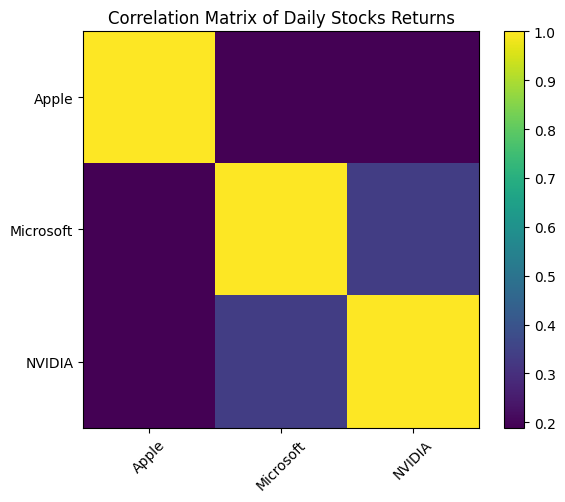

In [50]:
plt.figure(figsize=(6,5))

plt.imshow(correlation_matrix, interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=45)

plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

plt.title("Correlation Matrix of Daily Stocks Returns")

# SAVE HERE
plt.savefig(
    "stock_figures/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

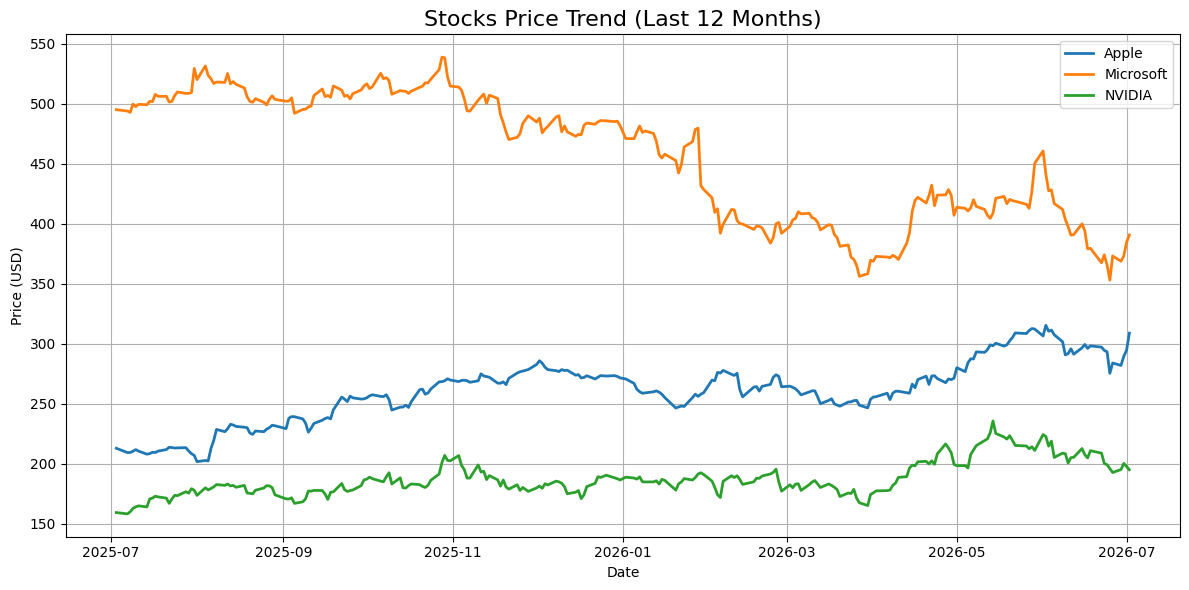

In [69]:
#Price Trend

plt.figure(figsize=(12,6))

for name, data in stocks_data.items():
    plt.plot(data.index, data["Close"], linewidth=2, label=name)

plt.title("Stocks Price Trend (Last 12 Months)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

# SAVE HERE
plt.savefig(
    "stock_figures/price_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

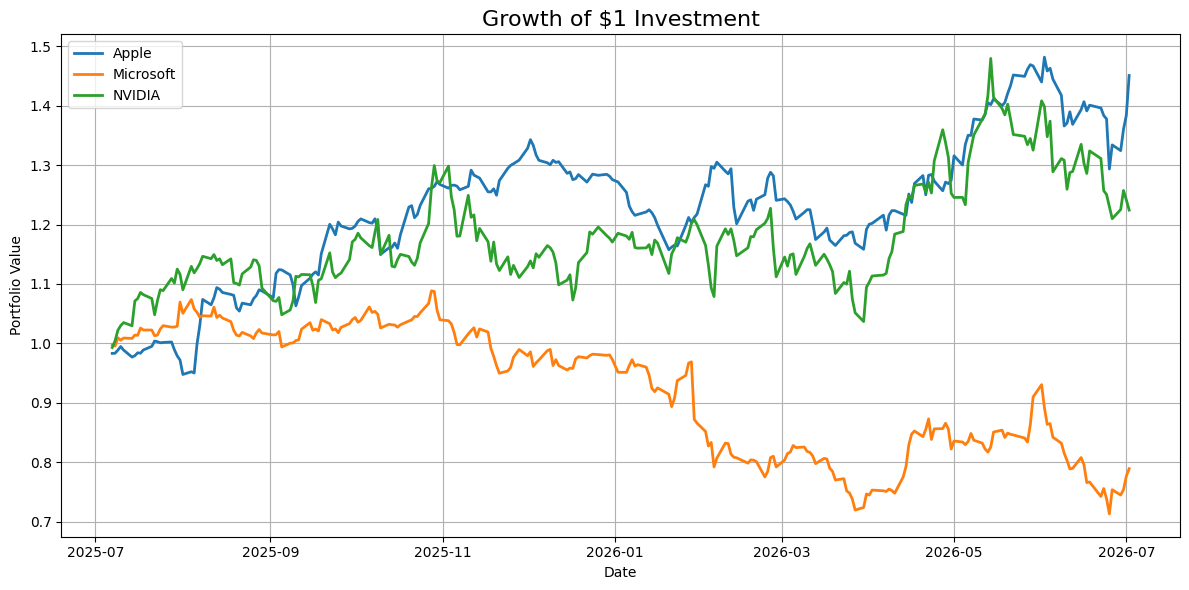

In [52]:
#Cumulative Return(Growth of $1)

plt.figure(figsize=(12,6))

for name, returns in stocks_returns.items():

    cumulative = (1 + returns).cumprod()

    plt.plot(cumulative.index,
             cumulative,
             linewidth=2,
             label=name)

plt.title("Growth of $1 Investment", fontsize=16)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()

plt.grid(True)

# SAVE HERE
plt.savefig(
    "stock_figures/Growth of $1 Investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

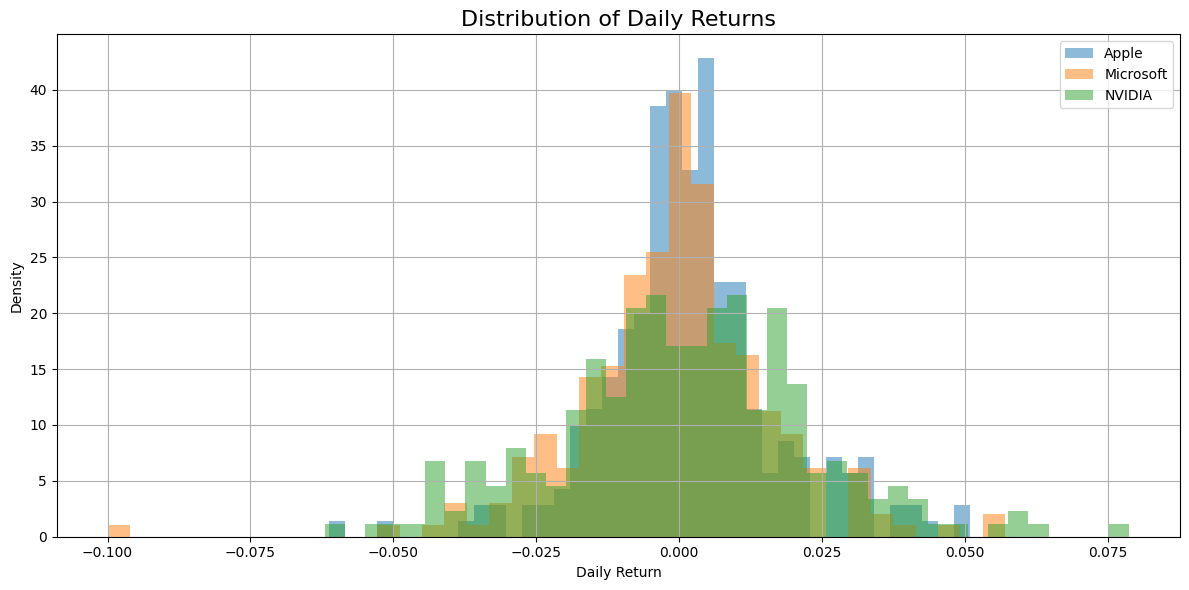

In [53]:
#Return Distribution

plt.figure(figsize=(12,6))

for name, returns in stocks_returns.items():

    plt.hist(
        returns,
        bins=40,
        alpha=0.5,
        density=True,
        label=name
    )

plt.title("Distribution of Daily Returns", fontsize=16)

plt.xlabel("Daily Return")

plt.ylabel("Density")

plt.legend()

plt.grid(True)

# SAVE HERE
plt.savefig(
    "stock_figures/Distribution of Daily Returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

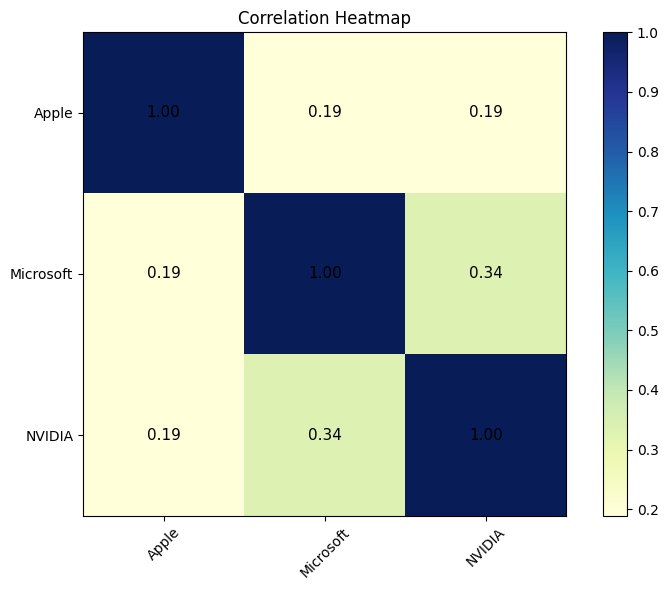

In [54]:
#Correlation Heatmap

returns_df = pd.DataFrame(stocks_returns)

corr = returns_df.corr()

plt.figure(figsize=(8,6))

plt.imshow(corr,
           cmap="YlGnBu",
           interpolation="nearest")

plt.colorbar()

plt.xticks(
    np.arange(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    np.arange(len(corr.columns)),
    corr.columns
)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=11
        )

plt.title("Correlation Heatmap")

# SAVE HERE
plt.savefig(
    "stock_figures/Correlation Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

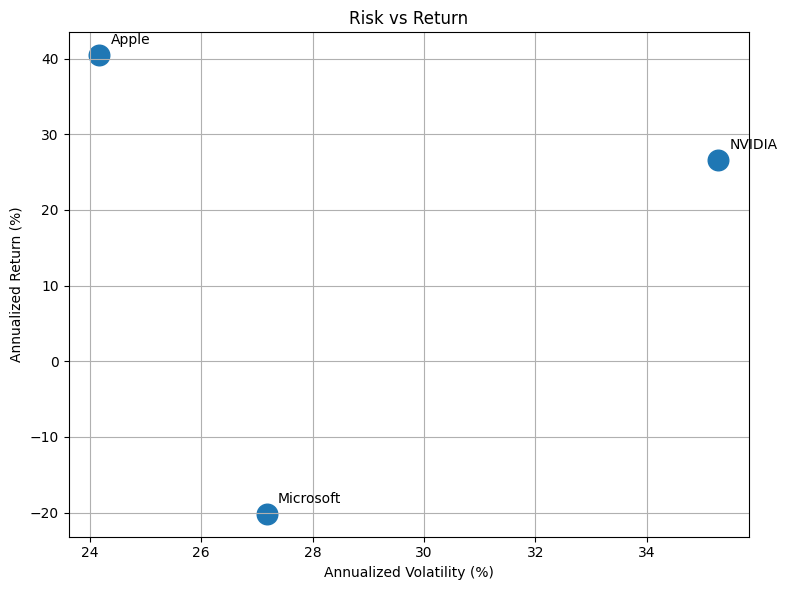

In [55]:
#Risk vs Return Scatter Plot

risk = []

annual_return = []

for name, returns in stocks_returns.items():

    annual_return.append(
        returns.mean()*252*100
    )

    risk.append(
        returns.std()*np.sqrt(252)*100
    )


plt.figure(figsize=(8,6))

plt.scatter(
    risk,
    annual_return,
    s=220
)

for i, name in enumerate(stocks_returns.keys()):

    plt.annotate(
        name,
        (risk[i], annual_return[i]),
        xytext=(8,8),
        textcoords="offset points"
    )

plt.xlabel("Annualized Volatility (%)")

plt.ylabel("Annualized Return (%)")

plt.title("Risk vs Return")

plt.grid(True)

# SAVE HERE
plt.savefig(
    "stock_figures/Risk vs Return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

plt.show()

In [66]:
ticker = yf.Ticker("AAPL")

ticker.news[:5]

[{'id': '668796e0-7705-3d22-a7ea-5126ebd9dbc8',
  'content': {'id': '668796e0-7705-3d22-a7ea-5126ebd9dbc8',
   'contentType': 'STORY',
   'title': 'Western Digital, Sandisk, AMD, ASML, TeraWulf, Strategy, and More Stocks That Explain Today’s Market',
   'description': '',
   'summary': 'FEATURE  Maybe the stock market just needed a long weekend to regain its confidence.\xa0 Stocks were gaining in premarket Monday with technology stocks among those trading higher. Semiconductor companies were particularly prominent as the artificial-intelligence trade regained momentum.',
   'pubDate': '2026-07-06T13:22:00Z',
   'displayTime': '2026-07-06T13:22:00Z',
   'isHosted': False,
   'bypassModal': False,
   'previewUrl': 'https://finance.yahoo.com/m/668796e0-7705-3d22-a7ea-5126ebd9dbc8/western-digital-sandisk-.html',
   'thumbnail': {'originalUrl': 'https://media.zenfs.com/en/Barrons.com/9f1cccbe893f7ae9c28365b26a13c262',
    'originalWidth': 1280,
    'originalHeight': 640,
    'caption': '',
